# OBSERVE RADIATION DATA AND FORMAT IT INTO THE CORRECT FORMAT

In [82]:
import sys
print(sys.executable)

/usr/bin/python


In [83]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import seaborn as sns

In [84]:
#this is a function from another notebook originally, but the code is basically the same and allows us to see the data on a map
def plotColsOnMap(cols,df):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        #we want to see the coastlines on the globe and only take not null values
        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]

        #scatter plot is created
        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col],
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree(),
        )

        #we want to see the entire globe and not just the values 
        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        plt.colorbar(sc, ax=ax, label="color scale")
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

We open the files

In [85]:
source = xr.open_dataset("./nc/radiation/data_stream-moda_stepType-avgad.nc")
print(source)

<xarray.Dataset> Size: 50MB
Dimensions:     (valid_time: 12, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01T06:00:00 ... 2024-...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 192B ...
Data variables:
    ssrc        (valid_time, latitude, longitude) float32 50MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-08T12:43 GRIB to CDM+CF via cfgrib-0.9.1...


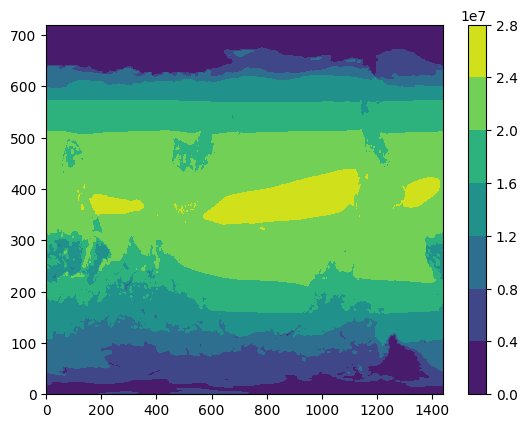

In [86]:
source_m = source["ssrc"].mean(dim="valid_time")
#then the data can be plotted
title = "testplot"
col = plt.contourf(source_m)
#adding the colorbar
plt.colorbar(col, orientation='vertical')
plt.show()

In [87]:
#source_mm = source_m.groupby(['latitude','longitude']).mean()
solar_df = source_m.to_dataframe().reset_index()
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038240 entries, 0 to 1038239
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   latitude   1038240 non-null  float64
 1   longitude  1038240 non-null  float64
 2   number     1038240 non-null  int64  
 3   ssrc       1038240 non-null  float32
dtypes: float32(1), float64(2), int64(1)
memory usage: 27.7 MB


In [88]:
solar_df.describe()

,latitude,longitude,number,ssrc
count,1.038240e+06,1.038240e+06,1038240.0,1.038240e+06
mean,0.000000e+00,1.798750e+02,0.0,1.487173e+07
std,5.203367e+01,1.039231e+02,0.0,7.476412e+06
min,-9.000000e+01,0.000000e+00,0.0,1.180555e+06
25%,-4.500000e+01,8.993750e+01,0.0,8.298923e+06
50%,0.000000e+00,1.798750e+02,0.0,1.657181e+07
75%,4.500000e+01,2.698125e+02,0.0,2.158789e+07
max,9.000000e+01,3.597500e+02,0.0,2.602250e+07


Since values are clearly floating point for coordinates, they need to be rounded first.

In [89]:
lat_rnd = np.round(solar_df['latitude'])
lon_rnd = np.round(solar_df['longitude'])

data = solar_df[["ssrc"]]

solar_df_rnd = pd.concat([lat_rnd, lon_rnd,data], axis=1).astype({"latitude":"int32", "longitude": "int32"})
solar_df_rnd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038240 entries, 0 to 1038239
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   latitude   1038240 non-null  int32  
 1   longitude  1038240 non-null  int32  
 2   ssrc       1038240 non-null  float32
dtypes: float32(1), int32(2)
memory usage: 11.9 MB


In [90]:
solar_df_avg = solar_df_rnd.groupby(['latitude', 'longitude']).mean().reset_index()
solar_df_avg.rename(columns={'latitude':"LATITUDE","longitude":"LONGITUDE"}, inplace=True)
solar_df_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65341 entries, 0 to 65340
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LATITUDE   65341 non-null  int32  
 1   LONGITUDE  65341 non-null  int32  
 2   ssrc       65341 non-null  float32
dtypes: float32(1), int32(2)
memory usage: 765.8 KB


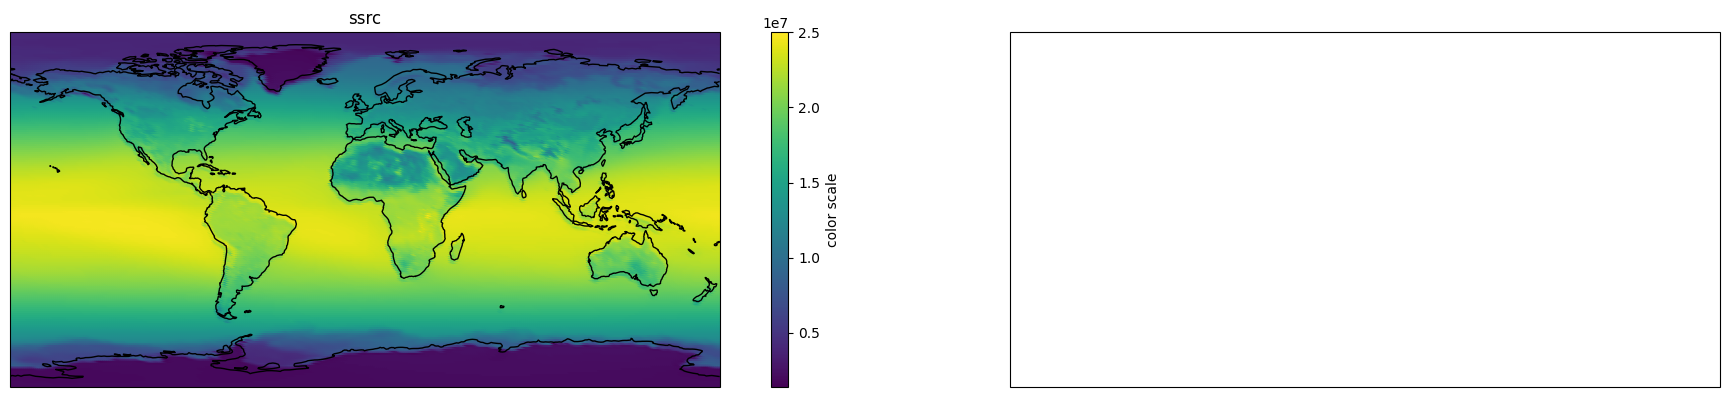

In [91]:
plotColsOnMap(["ssrc"], solar_df_avg)

In [92]:
solar_df_avg.describe()

,LATITUDE,LONGITUDE,ssrc
count,65341.000000,65341.000000,65341.00
mean,0.000000,180.000000,14821400.00
std,52.249802,104.212121,7494931.50
min,-90.000000,0.000000,1393395.25
25%,-45.000000,90.000000,8167318.50
50%,0.000000,180.000000,16540439.00
75%,45.000000,270.000000,21579202.00
max,90.000000,360.000000,25009332.00


In [93]:
conversion_mask = solar_df_avg["LONGITUDE"]>=180
solar_df_avg.loc[conversion_mask, "LONGITUDE"]=solar_df_avg["LONGITUDE"][conversion_mask]-np.ones(len(solar_df_avg["LONGITUDE"][conversion_mask]))*360
solar_df_avg.describe()

,LATITUDE,LONGITUDE,ssrc
count,65341.000000,65341.000000,65341.00
mean,0.000000,-0.498615,14821400.00
std,52.249802,103.779408,7494931.50
min,-90.000000,-180.000000,1393395.25
25%,-45.000000,-90.000000,8167318.50
50%,0.000000,0.000000,16540439.00
75%,45.000000,89.000000,21579202.00
max,90.000000,179.000000,25009332.00


In [94]:
solar_df_avg["ssrc"] = solar_df_avg["ssrc"]/(3*60*60)

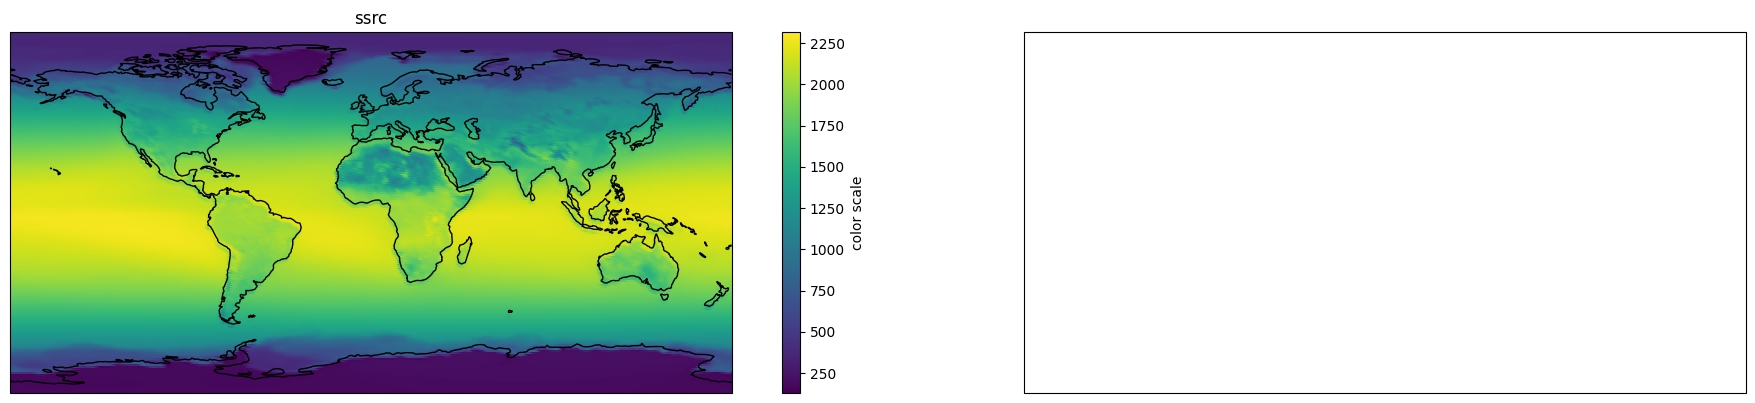

In [95]:
plotColsOnMap(["ssrc"], solar_df_avg)